## Домашнє завдання до модуля «Вступ до NLP»

### КРОК 1. Імпорт бібліотек і перевірка середовища

In [10]:
# ============================================
# КРОК 1.1. Імпортування необхідних бібліотек
# ============================================

# Стандартні бібліотеки Python
import os
import re
import sys
import random
import warnings
from pathlib import Path

# Робота з даними та візуалізація
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: поділ даних, векторизація, моделі та метрики
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# Обробка тексту
import nltk
from nltk.corpus import stopwords

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Налаштування
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Виведення інформації про середовище
print("Python version:")
print(sys.version)

print("\nОсновні бібліотеки:")
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", __import__("sklearn").__version__)
print("TensorFlow:", tf.__version__)

Python version:
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]

Основні бібліотеки:
pandas: 1.5.3
NumPy: 1.23.5
scikit-learn: 1.2.2
TensorFlow: 2.10.0


In [11]:
# ==================================================
# КРОК 1.2. Перевірка доступності GPU
# ==================================================

gpus = tf.config.list_physical_devices("GPU")

print("Доступні GPU для TensorFlow:")
print(gpus)

if gpus:
    try:
        # TensorFlow не займатиме всю пам'ять відеокарти одразу,
        # а використовуватиме її поступово за потреби.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("\nGPU знайдено.")
        print("Режим memory growth успішно увімкнено.")

    except RuntimeError as error:
        print("\nGPU знайдено, але memory growth не вдалося налаштувати:")
        print(error)

else:
    print("\nGPU не знайдено TensorFlow.")
    print("Навчання поки виконуватиметься на CPU.")

Доступні GPU для TensorFlow:
[]

GPU не знайдено TensorFlow.
Навчання поки виконуватиметься на CPU.


In [12]:
# ===================================================
# КРОК 1.3. Завантаження англійських стоп-слів NLTK
# ===================================================

try:
    stop_words = set(stopwords.words("english"))
    print("Стоп-слова вже доступні.")

except LookupError:
    print("Завантажуємо набір англійських стоп-слів...")
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))
    print("Стоп-слова успішно завантажено.")

print(f"\nКількість англійських стоп-слів: {len(stop_words)}")
print("Перші 20 стоп-слів:")
print(sorted(stop_words)[:20])

Стоп-слова вже доступні.

Кількість англійських стоп-слів: 198
Перші 20 стоп-слів:
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


### Крок 2. Завантаження та первинний аналіз даних

In [13]:
# ==========================================================
# КРОК 2.1. Завантаження датасету
# ==========================================================

DATA_PATH = Path("datasets") / "spam.csv"

print(f"Шлях до датасету: {DATA_PATH}")
print(f"Файл існує: {DATA_PATH.exists()}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Файл не знайдено: {DATA_PATH.resolve()}\n"
        "Перевір, чи файл spam.csv знаходиться у папці datasets."
    )

# Завантажуємо CSV.
# encoding='latin-1' потрібне для поширеної версії spam.csv,
# у якій звичайне UTF-8 декодування може викликати помилку.
df = pd.read_csv(DATA_PATH, encoding="latin-1")

print(f"\nРозмір датасету: {df.shape[0]} рядків × {df.shape[1]} колонок")

print("\nНазви колонок:")
print(df.columns.tolist())

print("\nПерші 5 рядків:")
display(df.head())

Шлях до датасету: datasets\spam.csv
Файл існує: True

Розмір датасету: 5572 рядків × 5 колонок

Назви колонок:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Перші 5 рядків:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [14]:
# ==========================================================
# КРОК 2.2. Очищення структури датасету
# ==========================================================

# Залишаємо лише цільову мітку та текст повідомлення.
df = df[["v1", "v2"]].copy()

# Перейменовуємо колонки для зручної подальшої роботи.
df.columns = ["label", "text"]

print("Розмір датасету після вибору потрібних колонок:")
print(df.shape)

print("\nТипи даних:")
display(df.dtypes)

print("\nПерші 5 рядків очищеного датасету:")
display(df.head())

print("\nКількість пропущених значень:")
display(df.isna().sum())

print("\nКількість повних дублікатів рядків:")
print(df.duplicated().sum())

Розмір датасету після вибору потрібних колонок:
(5572, 2)

Типи даних:


label    object
text     object
dtype: object


Перші 5 рядків очищеного датасету:


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Кількість пропущених значень:


label    0
text     0
dtype: int64


Кількість повних дублікатів рядків:
403


In [15]:
# ==========================================================
# КРОК 2.3. Видалення повних дублікатів
# ==========================================================

rows_before = len(df)

# Видаляємо рядки, де повторюються і label, і text.
df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
duplicates_removed = rows_before - rows_after

print(f"Кількість рядків до видалення дублікатів: {rows_before}")
print(f"Кількість видалених дублікатів: {duplicates_removed}")
print(f"Кількість рядків після видалення: {rows_after}")

print("\nПовторна перевірка дублікатів:")
print(f"Залишилось повних дублікатів: {df.duplicated().sum()}")

Кількість рядків до видалення дублікатів: 5572
Кількість видалених дублікатів: 403
Кількість рядків після видалення: 5169

Повторна перевірка дублікатів:
Залишилось повних дублікатів: 0


Розподіл класів:


,Кількість повідомлень,"Частка, %"
ham,4516,87.37
spam,653,12.63


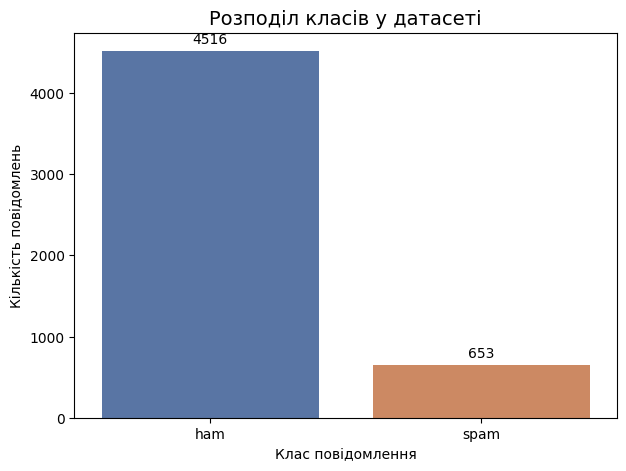

In [16]:
# ==========================================================
# КРОК 2.4. Аналіз розподілу класів ham / spam
# ==========================================================

# Абсолютна кількість повідомлень кожного класу.
class_counts = df["label"].value_counts()

# Відсоткова частка кожного класу.
class_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Об'єднуємо результати в одну таблицю.
class_distribution = pd.DataFrame({
    "Кількість повідомлень": class_counts,
    "Частка, %": class_percentages
})

print("Розподіл класів:")
display(class_distribution)

# Візуалізація розподілу класів.
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="label",
    order=["ham", "spam"],
    palette={"ham": "#4C72B0", "spam": "#DD8452"}
)

plt.title("Розподіл класів у датасеті", fontsize=14)
plt.xlabel("Клас повідомлення")
plt.ylabel("Кількість повідомлень")

# Відображаємо точну кількість над кожним стовпчиком.
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

#### Висновок щодо розподілу класів:

У датасеті переважає клас `ham`: 4 516 повідомлень, або 87.37%.
Клас `spam` містить 653 повідомлення, або 12.63%.

Отже, набір даних є незбалансованим. Через це метрика Accuracy сама по собі не є достатньою для оцінки моделі: класифікатор, який завжди прогнозує `ham`, теоретично може отримати приблизно 87% Accuracy, але не виявить жодного спам-повідомлення. Тому надалі для оцінювання моделей також використовуватимуться Precision, Recall, F1-score та ROC-AUC для класу `spam`.

In [17]:
# ==========================================================
# КРОК 2.5. Аналіз прикладів і довжини текстів
# ==========================================================

# Кількість символів у кожному повідомленні.
df["text_length"] = df["text"].str.len()

# Кількість слів у кожному повідомленні.
df["word_count"] = df["text"].str.split().str.len()

print("Статистика довжини повідомлень за класами:")
display(
    df.groupby("label")[["text_length", "word_count"]]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

print("\nПриклади легітимних повідомлень (ham):")
display(
    df.loc[df["label"] == "ham", ["text"]]
      .sample(n=3, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

print("\nПриклади спам-повідомлень (spam):")
display(
    df.loc[df["label"] == "spam", ["text"]]
      .sample(n=3, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

Статистика довжини повідомлень за класами:


text_length                         word_count                       
            count    mean median min  max      count   mean median min  max
label                                                                      
ham          4516   70.46   52.0   2  910       4516  14.13   11.0   1  171
spam          653  137.89  149.0  13  224        653  23.68   25.0   2   35


Приклади легітимних повідомлень (ham):


,text
0,"Come to me, slave. Your doing it again ... Goi..."
1,U meet other fren dun wan meet me ah... Muz b ...
2,"G says you never answer your texts, confirm/deny"



Приклади спам-повідомлень (spam):


,text
0,"Romantic Paris. 2 nights, 2 flights from å£79 ..."
1,"URGENT! Your mobile No *********** WON a å£2,0..."
2,Free 1st week entry 2 TEXTPOD 4 a chance 2 win...


#### Висновок щодо довжини повідомлень:

Спам-повідомлення в середньому довші за легітимні: 
- середня довжина класу `спам` становить 137.89 символів (23.68 слів);
- середня довжина класу `ham` становить 70.46 символів (14.13 слів). <br>
<p> Однак діапазони значень перетинаються: деякі легітимні повідомлення можуть бути довшими за спам. Тому для класифікації необхідно враховувати не лише довжину, а й зміст тексту через BoW, TF-IDF та ембединг-представлення.

### Крок 3. Підготовка тексту для навчання моделей. Попередня обробка текстових даних

In [18]:
# ==========================================================
# КРОК 3.1. Функція очищення англомовного тексту
# ==========================================================

def clean_text(text: str) -> str:
    """
    Очищує текст повідомлення для класичних моделей NLP.

    Послідовність обробки:
    1. Перетворення тексту на нижній регістр.
    2. Видалення URL-адрес.
    3. Видалення HTML-тегів.
    4. Заміна всіх символів, окрім латинських літер, пробілами.
    5. Видалення зайвих пробілів.
    6. Видалення англійських стоп-слів.
    """

    # Захист від потенційних пропусків або нестрокових значень.
    if not isinstance(text, str):
        return ""

    # Нижній регістр.
    text = text.lower()

    # URL: http://..., https://..., www....
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # HTML-теги: <br>, <a href=...>, тощо.
    text = re.sub(r"<.*?>", " ", text)

    # Залишаємо лише латинські літери та пробіли.
    text = re.sub(r"[^a-z\s]", " ", text)

    # Розбиваємо текст на слова та прибираємо стоп-слова.
    tokens = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(tokens)

In [19]:
# ==========================================================
# КРОК 3.2. Створення очищеної текстової колонки
# ==========================================================

# Застосовуємо функцію очищення до кожного повідомлення.
df["clean_text"] = df["text"].apply(clean_text)

print("Перші 10 повідомлень: оригінальний та очищений текст")

display(
    df[["label", "text", "clean_text"]]
    .head(10)
)

# Перевіряємо, чи не утворилися порожні тексти після очищення.
empty_clean_texts = (df["clean_text"].str.len() == 0).sum()

print(f"Кількість порожніх текстів після очищення: {empty_clean_texts}")
print(f"Частка порожніх текстів: {empty_clean_texts / len(df):.2%}")

Перші 10 повідомлень: оригінальний та очищений текст


,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,ham,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,spam,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,spam,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


Кількість порожніх текстів після очищення: 7
Частка порожніх текстів: 0.14%


In [20]:
# ==========================================================
# КРОК 3.3. Кодування класів ham / spam у 0 / 1
# ==========================================================

LABEL_MAPPING = {
    "ham": 0,
    "spam": 1
}

df["target"] = df["label"].map(LABEL_MAPPING)

print("Відповідність класів:")
print(LABEL_MAPPING)

print("\nРозподіл числової цільової змінної:")
display(
    df["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="Кількість повідомлень")
)

print("\nПеревірка пропусків після кодування:")
print(f"Пропуски в target: {df['target'].isna().sum()}")

print("\nПерші 5 рядків підготовленого датасету:")
display(
    df[["label", "target", "text", "clean_text"]]
    .head()
)

Відповідність класів:
{'ham': 0, 'spam': 1}

Розподіл числової цільової змінної:


,target,Кількість повідомлень
0,0,4516
1,1,653



Перевірка пропусків після кодування:
Пропуски в target: 0

Перші 5 рядків підготовленого датасету:


,label,target,text,clean_text
0,ham,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [21]:
# ==========================================================
# КРОК 3.4. Поділ даних на навчальну та валідаційну вибірки
# ==========================================================

# Ознаки: очищений текст повідомлень.
X = df["clean_text"]

# Цільова змінна: 0 = ham, 1 = spam.
y = df["target"]

# Поділ 80% / 20% зі збереженням пропорцій класів.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Розмір вибірок:")
print(f"Навчальна вибірка: {X_train.shape[0]} повідомлень")
print(f"Валідаційна вибірка: {X_val.shape[0]} повідомлень")

print("\nРозподіл класів у навчальній вибірці:")
train_distribution = pd.DataFrame({
    "Кількість": y_train.value_counts().sort_index(),
    "Частка, %": (y_train.value_counts(normalize=True)
                  .sort_index()
                  .mul(100)
                  .round(2))
})
display(train_distribution)

print("\nРозподіл класів у валідаційній вибірці:")
val_distribution = pd.DataFrame({
    "Кількість": y_val.value_counts().sort_index(),
    "Частка, %": (y_val.value_counts(normalize=True)
                  .sort_index()
                  .mul(100)
                  .round(2))
})
display(val_distribution)

Розмір вибірок:
Навчальна вибірка: 4135 повідомлень
Валідаційна вибірка: 1034 повідомлень

Розподіл класів у навчальній вибірці:


,Кількість,"Частка, %"
0,3613,87.38
1,522,12.62



Розподіл класів у валідаційній вибірці:


,Кількість,"Частка, %"
0,903,87.33
1,131,12.67


### Крок 4. Bag of Words та TF-IDF

In [22]:
# ==========================================================
# КРОК 4.1. Bag of Words: CountVectorizer
# ==========================================================

bow_vectorizer = CountVectorizer(
    max_features=5000,      # Обмежуємо словник 5 000 найчастотнішими ознаками.
    ngram_range=(1, 2),     # Використовуємо окремі слова та біграми.
    min_df=2,               # Відкидаємо токени, що трапляються лише в одному листі.
    max_df=0.95             # Відкидаємо токени з понад 95% документної частоти.
)

# Навчаємо словник тільки на train, щоб уникнути витоку даних із validation.
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Для validation лише застосовуємо вже сформований train-словник.
X_val_bow = bow_vectorizer.transform(X_val)

print("Розмірність BoW-матриць:")
print(f"X_train_bow: {X_train_bow.shape}")
print(f"X_val_bow:   {X_val_bow.shape}")

print(f"\nКількість ознак у BoW-словнику: {len(bow_vectorizer.vocabulary_)}")

print("\nПерші 30 ознак зі словника:")
print(bow_vectorizer.get_feature_names_out()[:30])

print("\nКількість ненульових значень:")
print(f"Train: {X_train_bow.nnz}")
print(f"Validation: {X_val_bow.nnz}")

Розмірність BoW-матриць:
X_train_bow: (4135, 5000)
X_val_bow:   (1034, 5000)

Кількість ознак у BoW-словнику: 5000

Перші 30 ознак зі словника:
['aah' 'aathi' 'abi' 'ability' 'abiola' 'able' 'able come' 'able deliver'
 'able get' 'able pay' 'abt' 'abt already' 'abt tht' 'abt ur' 'aburo'
 'aburo enjoy' 'ac' 'acc' 'accept' 'access' 'access number' 'accident'
 'accident claim' 'accidentally' 'accidentally deleted' 'accordingly'
 'account' 'account details' 'account lt' 'account number']

Кількість ненульових значень:
Train: 35893
Validation: 8032


Метрики моделі Logistic Regression + BoW:
Accuracy: 0.9768
Precision (spam): 0.9908
Recall (spam): 0.8244
F1-score (spam): 0.9000
ROC-AUC: 0.9907

Classification report:
              precision    recall  f1-score   support

         ham     0.9751    0.9989    0.9869       903
        spam     0.9908    0.8244    0.9000       131

    accuracy                         0.9768      1034
   macro avg     0.9830    0.9117    0.9434      1034
weighted avg     0.9771    0.9768    0.9759      1034

Confusion matrix:


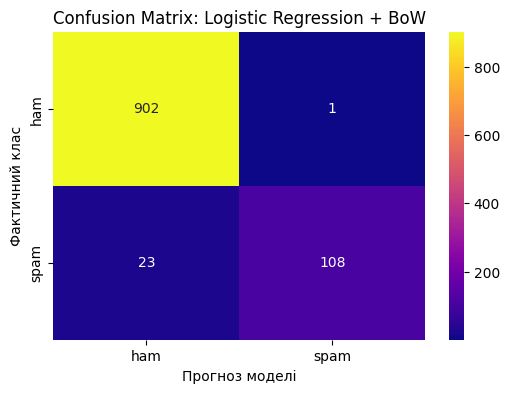

In [23]:
# =============================================================
# КРОК 4.2. Навчання та оцінювання Logistic Regression для BoW
# =============================================================

# Створюємо модель Logistic Regression.
bow_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver="liblinear"
)

# Навчання моделі на BoW-представленні навчальної вибірки.
bow_model.fit(X_train_bow, y_train)

# Класові прогнози: 0 = ham, 1 = spam.
y_pred_bow = bow_model.predict(X_val_bow)

# Імовірність належності повідомлення до позитивного класу spam (1).
y_proba_bow = bow_model.predict_proba(X_val_bow)[:, 1]

# Обчислення метрик.
bow_accuracy = accuracy_score(y_val, y_pred_bow)
bow_precision = precision_score(y_val, y_pred_bow, zero_division=0)
bow_recall = recall_score(y_val, y_pred_bow, zero_division=0)
bow_f1 = f1_score(y_val, y_pred_bow, zero_division=0)
bow_auc = roc_auc_score(y_val, y_proba_bow)

# Зберігаємо результати першої моделі.
bow_results = {
    "Модель": "Logistic Regression + BoW",
    "Accuracy": bow_accuracy,
    "Precision (spam)": bow_precision,
    "Recall (spam)": bow_recall,
    "F1-score (spam)": bow_f1,
    "ROC-AUC": bow_auc
}

print("Метрики моделі Logistic Regression + BoW:")
for metric, value in bow_results.items():
    if metric != "Модель":
        print(f"{metric}: {value:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_val,
        y_pred_bow,
        target_names=["ham", "spam"],
        digits=4,
        zero_division=0
    )
)

print("Confusion matrix:")
bow_cm = confusion_matrix(y_val, y_pred_bow)

plt.figure(figsize=(6, 4))
sns.heatmap(
    bow_cm,
    annot=True,
    fmt="d",
    cmap="plasma",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)

plt.title("Confusion Matrix: Logistic Regression + BoW")
plt.xlabel("Прогноз моделі")
plt.ylabel("Фактичний клас")
plt.show()

#### Висновки:

- True Negative = 902: 902 легітимні повідомлення правильно визначені як ham.
- False Positive = 1: лише один нормальний лист помилково потрапив до спаму. 
- False Negative = 23: 23 спам-повідомлення модель помилково пропустила як ham.
- True Positive = 108: 108 спам-листів правильно виявлено.

Модель дуже обережна, коли позначає лист як спам: її Precision майже 99.1%. Але ціною цього є 23 пропущені спам-листи, тому Recall нижчий — 82.44%. <br> 
У реальному сервісі це можна регулювати зміною порогу класифікації: наприклад, позначати як спам листи з імовірністю не від 0.50, а від 0.35–0.45, якщо важливіше не пропустити небажану кореспонденцію.

In [24]:
# ==========================================================
# КРОК 4.3. TF-IDF: TfidfVectorizer
# ==========================================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # До 5 000 найбільш інформативних ознак.
    ngram_range=(1, 2),     # Уніграми та біграми.
    min_df=2,               # Ігноруємо токени лише з одного повідомлення.
    max_df=0.95,            # Відкидаємо надто поширені токени.
    sublinear_tf=True       # Застосовуємо log(1 + tf) для частоти токена.
)

# Словник і IDF-ваги формуються тільки за навчальною вибіркою.
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Validation використовує рівно той самий словник і ваги.
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print("Розмірність TF-IDF-матриць:")
print(f"X_train_tfidf: {X_train_tfidf.shape}")
print(f"X_val_tfidf:   {X_val_tfidf.shape}")

print(f"\nКількість ознак у TF-IDF-словнику: {len(tfidf_vectorizer.vocabulary_)}")

print("\nПерші 30 ознак зі словника:")
print(tfidf_vectorizer.get_feature_names_out()[:30])

print("\nКількість ненульових значень:")
print(f"Train: {X_train_tfidf.nnz}")
print(f"Validation: {X_val_tfidf.nnz}")

Розмірність TF-IDF-матриць:
X_train_tfidf: (4135, 5000)
X_val_tfidf:   (1034, 5000)

Кількість ознак у TF-IDF-словнику: 5000

Перші 30 ознак зі словника:
['aah' 'aathi' 'abi' 'ability' 'abiola' 'able' 'able come' 'able deliver'
 'able get' 'able pay' 'abt' 'abt already' 'abt tht' 'abt ur' 'aburo'
 'aburo enjoy' 'ac' 'acc' 'accept' 'access' 'access number' 'accident'
 'accident claim' 'accidentally' 'accidentally deleted' 'accordingly'
 'account' 'account details' 'account lt' 'account number']

Кількість ненульових значень:
Train: 35893
Validation: 8032


Метрики моделі Logistic Regression + TF-IDF:
Accuracy: 0.9555
Precision (spam): 0.9885
Recall (spam): 0.6565
F1-score (spam): 0.7890
ROC-AUC: 0.9928

Classification report:
              precision    recall  f1-score   support

         ham     0.9525    0.9989    0.9751       903
        spam     0.9885    0.6565    0.7890       131

    accuracy                         0.9555      1034
   macro avg     0.9705    0.8277    0.8821      1034
weighted avg     0.9570    0.9555    0.9516      1034

Confusion matrix:


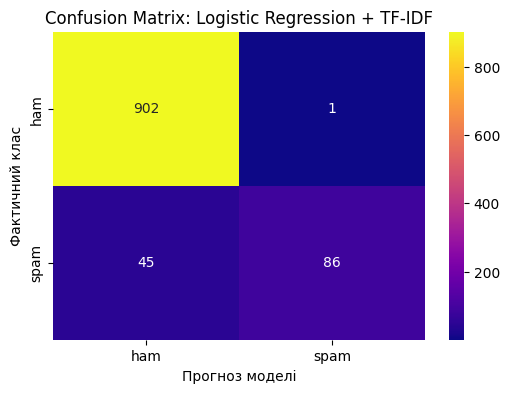

In [25]:
# ================================================================
# КРОК 4.4. Навчання та оцінювання Logistic Regression для TF-IDF
# ================================================================

# Створюємо модель Logistic Regression для TF-IDF-ознак.
tfidf_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver="liblinear"
)

# Навчаємо модель на TF-IDF-представленні навчальної вибірки.
tfidf_model.fit(X_train_tfidf, y_train)

# Прогноз класу: 0 = ham, 1 = spam.
y_pred_tfidf = tfidf_model.predict(X_val_tfidf)

# Імовірність належності до позитивного класу spam.
y_proba_tfidf = tfidf_model.predict_proba(X_val_tfidf)[:, 1]

# Метрики якості.
tfidf_accuracy = accuracy_score(y_val, y_pred_tfidf)
tfidf_precision = precision_score(y_val, y_pred_tfidf, zero_division=0)
tfidf_recall = recall_score(y_val, y_pred_tfidf, zero_division=0)
tfidf_f1 = f1_score(y_val, y_pred_tfidf, zero_division=0)
tfidf_auc = roc_auc_score(y_val, y_proba_tfidf)

# Зберігаємо результати для фінального порівняння.
tfidf_results = {
    "Модель": "Logistic Regression + TF-IDF",
    "Accuracy": tfidf_accuracy,
    "Precision (spam)": tfidf_precision,
    "Recall (spam)": tfidf_recall,
    "F1-score (spam)": tfidf_f1,
    "ROC-AUC": tfidf_auc
}

print("Метрики моделі Logistic Regression + TF-IDF:")
for metric, value in tfidf_results.items():
    if metric != "Модель":
        print(f"{metric}: {value:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_val,
        y_pred_tfidf,
        target_names=["ham", "spam"],
        digits=4,
        zero_division=0
    )
)

print("Confusion matrix:")
tfidf_cm = confusion_matrix(y_val, y_pred_tfidf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    tfidf_cm,
    annot=True,
    fmt="d",
    cmap="plasma",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)

plt.title("Confusion Matrix: Logistic Regression + TF-IDF")
plt.xlabel("Прогноз моделі")
plt.ylabel("Фактичний клас")
plt.show()

#### Висновки:
Модель Logistic Regression + TF-IDF добре розділяє класи за оцінками ймовірностей, але при стандартному порозі 0.50 занадто обережно позначає листи як спам. Вона майже не відправляє легітимні повідомлення у спам, проте пропускає помітну частину реального спаму. <br>
Precision показує, наскільки рідко модель помилково називає нормальний лист спамом; Recall — яку частину справжнього спаму вона знаходить. F1-score є гармонійним середнім цих двох показників.

Сильні сторони:
- Дуже висока `Precision` — 98.85%. Якщо TF-IDF-модель класифікує лист як `spam`, майже напевно це справжній спам. Це корисно в системі, де критично не можна помилково приховати важливий легітимний лист.
- Високий `ROC-AUC` — 0.9928. Модель чудово ранжує повідомлення: загалом вона вміє давати більші значення імовірності для спаму, ніж для `ham.`
- Висока `Accuracy` — 95.55%. Однак через дисбаланс класів цю метрику не можна інтерпретувати ізольовано: 87.37% повідомлень у датасеті — це `ham`.

Основний недолік:
- `Recall` для спаму — лише 65.65%. Це означає, що модель пропускає приблизно 34.35% спам-листів. За 131 реального спам-повідомлення у валідаційній вибірці модель правильно знаходить приблизно 86, а близько 45 класифікує як `ham`.
- Через низький `Recall` зменшується і `F1-score` = 0.7890. Тобто модель дуже точна, але недостатньо «чутлива» до спаму.

#### Порівняння з BoW:

| Метрика для spam | BoW + Logistic Regression | TF-IDF + Logistic Regression | Кращий підхід              |
| ---------------- | ------------------------- | ---------------------------- | -------------------------- |
| Accuracy         | 0.9768                    | 0.9555                       | BoW                        |
| Precision        | 0.9908                    | 0.9885                       | BoW, різниця мінімальна    |
| Recall           | 0.8244                    | 0.6565                       | BoW                        |
| F1-score         | 0.9000                    | 0.7890                       | BoW                        |
| ROC-AUC          | 0.9907                    | 0.9928                       | TF-IDF, різниця мінімальна |

### Крок 5 — завантаження та використання попередньо навчених текстових ембедингів

In [26]:
# ==========================================================
# КРОК 5.1. Імпорт бібліотеки Gensim
# ==========================================================

import gensim
import gensim.downloader as api

print("Gensim:", gensim.__version__)
print("Gensim успішно імпортовано.")

Gensim: 4.3.2
Gensim успішно імпортовано.


In [27]:
# ==========================================================
# КРОК 5.2. Завантаження попередньо навченої моделі GloVe
# ==========================================================

import gensim.downloader as api

EMBEDDING_MODEL_NAME = "glove-wiki-gigaword-50"

print(f"Завантаження моделі: {EMBEDDING_MODEL_NAME}")

glove_model = api.load(EMBEDDING_MODEL_NAME)

print("\nМодель успішно завантажено.")
print(f"Розмірність векторів: {glove_model.vector_size}")
print(f"Кількість слів у словнику: {len(glove_model.key_to_index):,}")

# Перевіримо наявність кількох слів у словнику моделі.
test_words = ["free", "win", "prize", "message", "hello"]

print("\nПеревірка слів у словнику GloVe:")
for word in test_words:
    print(f"{word:10} -> {word in glove_model.key_to_index}")

Завантаження моделі: glove-wiki-gigaword-50

Модель успішно завантажено.
Розмірність векторів: 50
Кількість слів у словнику: 400,000

Перевірка слів у словнику GloVe:
free       -> True
win        -> True
prize      -> True
message    -> True
hello      -> True


In [28]:
# ==========================================================
# КРОК 5.3. Усереднення GloVe-векторів слів для тексту листа
# ==========================================================

def text_to_glove_vector(
    text: str,
    embedding_model,
    vector_size: int = 50
) -> np.ndarray:
    """
    Перетворює очищений текст повідомлення на один GloVe-вектор.

    Для тексту обчислюється середнє значення векторів усіх слів,
    присутніх у словнику попередньо навченої GloVe-моделі.
    """

    # Захист від порожніх або нестрокових значень.
    if not isinstance(text, str) or not text.strip():
        return np.zeros(vector_size, dtype=np.float32)

    # Беремо лише слова, для яких GloVe має попередньо навчений вектор.
    word_vectors = [
        embedding_model[word]
        for word in text.split()
        if word in embedding_model.key_to_index
    ]

    # Якщо жодне слово не знайдене у словнику — повертаємо нульовий вектор.
    if not word_vectors:
        return np.zeros(vector_size, dtype=np.float32)

    # Усереднюємо вектори всіх відомих слів повідомлення.
    return np.mean(word_vectors, axis=0).astype(np.float32)



# Перевірка функції на тестовому повідомленні


example_text = "free entry win prize claim"

example_vector = text_to_glove_vector(
    text=example_text,
    embedding_model=glove_model,
    vector_size=glove_model.vector_size
)

print("Тестовий текст:")
print(example_text)

print("\nРозмірність отриманого вектора:")
print(example_vector.shape)

print("\nПерші 10 значень вектора:")
print(example_vector[:10])

print("\nЧи є вектор ненульовим:")
print(np.any(example_vector != 0))

Тестовий текст:
free entry win prize claim

Розмірність отриманого вектора:
(50,)

Перші 10 значень вектора:
[-0.345312    0.66503996  0.133252    0.23848     0.23466778  0.1194252
 -0.52307403  0.373636    0.18089679  0.4325708 ]

Чи є вектор ненульовим:
True


In [30]:
# ==========================================================
# КРОК 5.4. Перетворення train / validation текстів у GloVe-вектори
# ==========================================================

# Перевіряємо, що train / validation split уже існує в пам'яті kernel.
required_variables = ["X_train", "X_val", "y_train", "y_val"]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Не знайдено змінні: "
        f"{', '.join(missing_variables)}.\n"
        "Виконай комірки Кроків 1.1–3.4 зверху вниз, "
        "а потім повтори цей блок."
    )

# Формуємо щільні матриці ембедингів.
# Один рядок = один лист; 50 стовпців = компоненти GloVe-вектора.
X_train_glove = np.vstack([
    text_to_glove_vector(
        text=text,
        embedding_model=glove_model,
        vector_size=glove_model.vector_size
    )
    for text in X_train
])

X_val_glove = np.vstack([
    text_to_glove_vector(
        text=text,
        embedding_model=glove_model,
        vector_size=glove_model.vector_size
    )
    for text in X_val
])

# Визначаємо тексти, для яких не знайдено жодного слова у словнику GloVe.
train_zero_vectors = np.all(X_train_glove == 0, axis=1).sum()
val_zero_vectors = np.all(X_val_glove == 0, axis=1).sum()

print("Розмірність GloVe-матриць:")
print(f"X_train_glove: {X_train_glove.shape}")
print(f"X_val_glove:   {X_val_glove.shape}")

print("\nКількість нульових векторів:")
print(
    f"Train: {train_zero_vectors} "
    f"({train_zero_vectors / len(X_train_glove):.2%})"
)
print(
    f"Validation: {val_zero_vectors} "
    f"({val_zero_vectors / len(X_val_glove):.2%})"
)

print("\nПеревірка першого GloVe-вектора навчальної вибірки:")
print(X_train_glove[0][:10])

Розмірність GloVe-матриць:
X_train_glove: (4135, 50)
X_val_glove:   (1034, 50)

Кількість нульових векторів:
Train: 11 (0.27%)
Validation: 3 (0.29%)

Перевірка першого GloVe-вектора навчальної вибірки:
[ 0.464744   -0.569078   -0.32145602 -0.66599596  0.181056   -0.78689003
 -0.612712    0.367764   -0.807096    0.04553241]


In [31]:
# ==========================================================
# КРОК 5.5. Масштабування GloVe-векторів і побудова DL-моделі
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Виконуємо масштабування лише на training-вибірці,
# щоб не допустити витоку інформації з validation.
glove_scaler = StandardScaler()

X_train_glove_scaled = glove_scaler.fit_transform(X_train_glove)
X_val_glove_scaled = glove_scaler.transform(X_val_glove)

print("Масштабування GloVe-векторів виконано.")
print(f"X_train_glove_scaled: {X_train_glove_scaled.shape}")
print(f"X_val_glove_scaled:   {X_val_glove_scaled.shape}")


# Фіксуємо seed для відтворюваного навчання нейромережі.
tf.keras.utils.set_random_seed(RANDOM_STATE)


# Створюємо нейронну мережу для бінарної класифікації spam / ham.
glove_dl_model = keras.Sequential([
    layers.Input(shape=(glove_model.vector_size,)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    # Sigmoid повертає імовірність того, що лист є spam.
    layers.Dense(1, activation="sigmoid")
])

# Компілюємо модель.
glove_dl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

print("\nАрхітектура нейронної мережі:")
glove_dl_model.summary()

Масштабування GloVe-векторів виконано.
X_train_glove_scaled: (4135, 50)
X_val_glove_scaled:   (1034, 50)

Архітектура нейронної мережі:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                3264      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 5,377
Trainable params: 5,377
Non-trai

In [32]:
# ==========================================================
# КРОК 5.6. Навчання DL-моделі на GloVe-ембедингах
# ==========================================================

# Обчислюємо ваги класів вручну.
# Рідкісніший клас spam отримає вищу вагу.
train_class_counts = y_train.value_counts().sort_index()

class_weight = {
    class_label: len(y_train) / (2 * count)
    for class_label, count in train_class_counts.items()
}

print("Ваги класів:")
print(class_weight)

# Раннє зупинення навчання.
# Повертаємо ваги тієї епохи, де validation loss був найменшим.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Якщо validation loss перестає покращуватися,
# зменшуємо швидкість навчання вдвічі.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# Навчаємо нейромережу.
history = glove_dl_model.fit(
    X_train_glove_scaled,
    y_train,
    validation_data=(X_val_glove_scaled, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

print(f"\nФактично виконано епох: {len(history.history['loss'])}")

Ваги класів:
{0: 0.5722391364517022, 1: 3.960727969348659}
Epoch 1/30
130/130 - 1s - loss: 0.4299 - accuracy: 0.8314 - precision: 0.4131 - recall: 0.7969 - auc: 0.8925 - val_loss: 0.3166 - val_accuracy: 0.8820 - val_precision: 0.5195 - val_recall: 0.9160 - val_auc: 0.9536 - lr: 0.0010 - 1s/epoch - 8ms/step
Epoch 2/30
130/130 - 0s - loss: 0.2702 - accuracy: 0.9076 - precision: 0.5877 - recall: 0.8985 - auc: 0.9562 - val_loss: 0.2465 - val_accuracy: 0.9101 - val_precision: 0.5969 - val_recall: 0.8931 - val_auc: 0.9672 - lr: 0.0010 - 185ms/epoch - 1ms/step
Epoch 3/30
130/130 - 0s - loss: 0.2386 - accuracy: 0.9170 - precision: 0.6161 - recall: 0.9100 - auc: 0.9652 - val_loss: 0.2359 - val_accuracy: 0.9101 - val_precision: 0.5941 - val_recall: 0.9160 - val_auc: 0.9735 - lr: 0.0010 - 172ms/epoch - 1ms/step
Epoch 4/30
130/130 - 0s - loss: 0.2117 - accuracy: 0.9245 - precision: 0.6427 - recall: 0.9061 - auc: 0.9727 - val_loss: 0.2213 - val_accuracy: 0.9217 - val_precision: 0.6302 - val_recall:

#### Результат навчання 

DL-модель навчалася 21 епоху з максимально дозволених 30, після чого EarlyStopping повернув ваги найкращої моделі з 16-ї епохи.
Найкраща епоха за val_loss:

| Показник             | Значення на 16-й епосі |
| -------------------- | ---------------------- |
| Train loss           | 0.1117                 |
| Train accuracy       | 0.9601                 |
| Validation loss      | 0.1489                 |
| Validation accuracy  | 0.9458                 |
| Validation precision | 0.7193                 |
| Validation recall    | 0.9389                 |
| Validation AUC       | 0.9804                 |


- Validation Recall = 0.9389: модель знаходить приблизно 93.89% усіх спам-повідомлень. Це суттєво краще за BoW-модель із Recall 0.8244 та TF-IDF-модель із Recall 0.6565.
- Validation Precision = 0.7193: серед листів, які нейромережа вважає спамом, приблизно 71.93% справді є спамом. Це нижче за Precision класичних моделей, але є наслідком застосування class_weight: модель навмисно стала чутливішою до спаму й погоджується частіше помилятися на користь виявлення небажаних листів.
- Validation AUC ≈ 0.9804: модель добре розрізняє спам і ham за прогнозованими імовірностями.
- Early Stopping зупинив навчання, бо після 16-ї епохи val_loss уже не покращувався стабільно. Це зменшує ризик перенавчання.

Метрики моделі GloVe + Deep Learning:
Accuracy: 0.9458
Precision (spam): 0.7193
Recall (spam): 0.9389
F1-score (spam): 0.8146
ROC-AUC: 0.9807

Classification report:
              precision    recall  f1-score   support

         ham     0.9907    0.9468    0.9683       903
        spam     0.7193    0.9389    0.8146       131

    accuracy                         0.9458      1034
   macro avg     0.8550    0.9429    0.8914      1034
weighted avg     0.9563    0.9458    0.9488      1034

Confusion matrix:
[[855  48]
 [  8 123]]


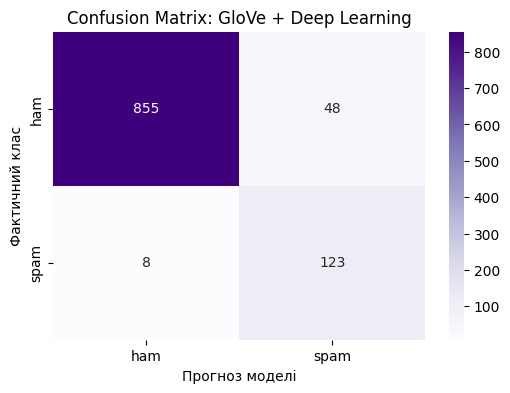

In [33]:
# ======================================================================================================
# КРОК 5.7. Оцінювання нейронної мережі на validation-вибірці. Оцінювання GloVe + Deep Learning моделі
# ======================================================================================================

# Отримуємо імовірність належності кожного листа до класу spam.
y_proba_glove_dl = glove_dl_model.predict(
    X_val_glove_scaled,
    verbose=0
).ravel()

# За стандартного порогу 0.50 формуємо класовий прогноз.
y_pred_glove_dl = (y_proba_glove_dl >= 0.50).astype(int)

# Розраховуємо метрики.
glove_dl_accuracy = accuracy_score(y_val, y_pred_glove_dl)
glove_dl_precision = precision_score(
    y_val,
    y_pred_glove_dl,
    zero_division=0
)
glove_dl_recall = recall_score(
    y_val,
    y_pred_glove_dl,
    zero_division=0
)
glove_dl_f1 = f1_score(
    y_val,
    y_pred_glove_dl,
    zero_division=0
)
glove_dl_auc = roc_auc_score(y_val, y_proba_glove_dl)

# Зберігаємо результати для фінального порівняння трьох підходів.
glove_dl_results = {
    "Модель": "GloVe + Deep Learning",
    "Accuracy": glove_dl_accuracy,
    "Precision (spam)": glove_dl_precision,
    "Recall (spam)": glove_dl_recall,
    "F1-score (spam)": glove_dl_f1,
    "ROC-AUC": glove_dl_auc
}

print("Метрики моделі GloVe + Deep Learning:")
for metric, value in glove_dl_results.items():
    if metric != "Модель":
        print(f"{metric}: {value:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_val,
        y_pred_glove_dl,
        target_names=["ham", "spam"],
        digits=4,
        zero_division=0
    )
)

# Матриця помилок.
glove_dl_cm = confusion_matrix(y_val, y_pred_glove_dl)

print("Confusion matrix:")
print(glove_dl_cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    glove_dl_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)

plt.title("Confusion Matrix: GloVe + Deep Learning")
plt.xlabel("Прогноз моделі")
plt.ylabel("Фактичний клас")
plt.show()

Отже:
- True Negative = 855: 855 звичайних листів правильно визначено як ham.
- False Positive = 48: 48 легітимних листів помилково потрапили до спаму.
- False Negative = 8: лише 8 реальних спам-листів модель пропустила.
- True Positive = 123: модель правильно знайшла 123 із 131 спам-повідомлення.

GloVe + Deep Learning має найкращий Recall для spam серед усіх трьох моделей:

| Модель                       | Precision spam | Recall spam | F1-score spam | ROC-AUC |
| ---------------------------- | -------------- | ----------- | ------------- | ------- |
| Logistic Regression + BoW    | 0.9908         | 0.8244      | 0.9000        | 0.9907  |
| Logistic Regression + TF-IDF | 0.9885         | 0.6565      | 0.7890        | 0.9928  |
| GloVe + Deep Learning        | 0.7193         | 0.9389      | 0.8146        | 0.9807  |

GloVe + Deep Learning є найкращим варіантом, якщо головний пріоритет — виявити якомога більше спам-повідомлень. Проте для поштового сервісу, де небажано помилково блокувати легітимні листи, BoW + Logistic Regression є безпечнішою моделлю через значно вищу Precision.

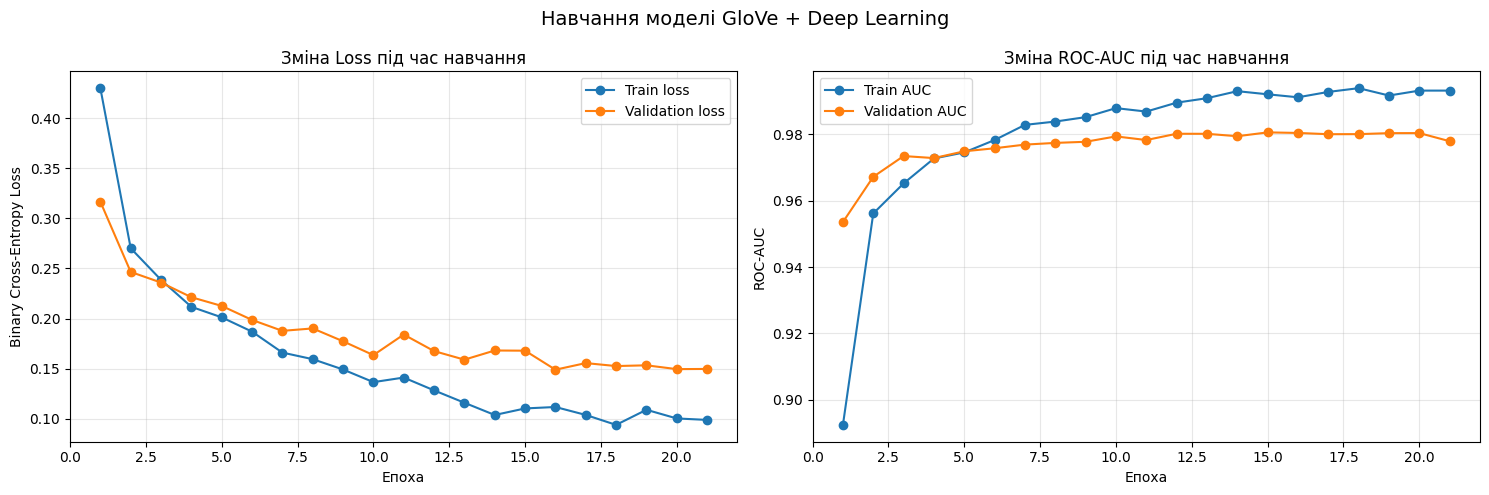

In [34]:
# ==========================================================
# КРОК 5.8. Графіки навчання GloVe + Deep Learning моделі
# ==========================================================

epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Графік функції втрат.
axes[0].plot(
    epochs,
    history.history["loss"],
    marker="o",
    label="Train loss"
)

axes[0].plot(
    epochs,
    history.history["val_loss"],
    marker="o",
    label="Validation loss"
)

axes[0].set_title("Зміна Loss під час навчання")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Графік AUC.
axes[1].plot(
    epochs,
    history.history["auc"],
    marker="o",
    label="Train AUC"
)

axes[1].plot(
    epochs,
    history.history["val_auc"],
    marker="o",
    label="Validation AUC"
)

axes[1].set_title("Зміна ROC-AUC під час навчання")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Навчання моделі GloVe + Deep Learning", fontsize=14)
plt.tight_layout()
plt.show()

### Аналіз графіків навчання нейронної мережі

Навчання моделі GloVe + Deep Learning протягом 21 епохи за функцією втрат Binary Cross-Entropy та метрикою ROC-AUC.

На перших епохах модель швидко навчається. Train loss зменшується приблизно з 0.43 до 0.20 протягом перших п'яти епох, а Validation loss — з 0.32 до 0.21.
Одночасно ROC-AUC швидко зростає та вже на ранніх епохах перевищує 0.97 для навчальної й валідаційної вибірок.

Після приблизно 10–12 епохи валідаційні показники виходять на плато. Validation AUC стабілізується біля 0.98, а Validation loss коливається в межах приблизно 0.15–0.17. Водночас Train loss продовжує зменшуватися, а Train AUC зростає майже до 0.99. Розрив між train і validation-кривими вказує на початок перенавчання.

Найменше значення Validation loss (0.1489) було досягнуто на 16-й епосі. Після цього подальше навчання не дало стабільного покращення, тому механізм Early Stopping зупинив процес на 21-й епосі та відновив найкращі ваги саме з 16-ї епохи.

Отже, Early Stopping спрацював коректно та запобіг зайвому навчанню моделі та зберіг стан із найкращою здатністю до узагальнення.

### Крок 6. Порівняння та інтерпретація результатів

In [35]:
# ==========================================================
# КРОК 6.1. Порівняння результатів усіх моделей
# ==========================================================

# Перевіряємо, чи збережені результати трьох моделей.
required_results = [
    "bow_results",
    "tfidf_results",
    "glove_dl_results"
]

missing_results = [
    variable
    for variable in required_results
    if variable not in globals()
]

if missing_results:
    raise NameError(
        "Не знайдено змінні: "
        f"{', '.join(missing_results)}.\n"
        "Виконай повторно комірки оцінювання моделей "
        "з Кроків 4.2, 4.4 та 5.7."
    )

# Об'єднуємо словники з результатами в одну таблицю.
results_df = pd.DataFrame([
    bow_results,
    tfidf_results,
    glove_dl_results
])

# Задаємо бажаний порядок колонок.
results_df = results_df[
    [
        "Модель",
        "Accuracy",
        "Precision (spam)",
        "Recall (spam)",
        "F1-score (spam)",
        "ROC-AUC"
    ]
]

# Сортуємо моделі за F1-score для класу spam.
results_df = results_df.sort_values(
    by="F1-score (spam)",
    ascending=False
).reset_index(drop=True)

print("Порівняння моделей:")
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision (spam)": "{:.4f}",
        "Recall (spam)": "{:.4f}",
        "F1-score (spam)": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Порівняння моделей:


,Модель,Accuracy,Precision (spam),Recall (spam),F1-score (spam),ROC-AUC
0,Logistic Regression + BoW,0.9768,0.9908,0.8244,0.9000,0.9907
1,GloVe + Deep Learning,0.9458,0.7193,0.9389,0.8146,0.9807
2,Logistic Regression + TF-IDF,0.9555,0.9885,0.6565,0.7890,0.9928


#### Висновок:
- BoW + Logistic Regression — найкраща за Accuracy та F1-score; найбільш збалансований варіант.
- GloVe + Deep Learning — найкраща за Recall; виявляє найбільше спаму, але частіше помилково позначає ham як spam.
- TF-IDF + Logistic Regression — має найвищий ROC-AUC, але за порогу 0.50 пропускає найбільше спаму, тому має найнижчий Recall і F1-score.

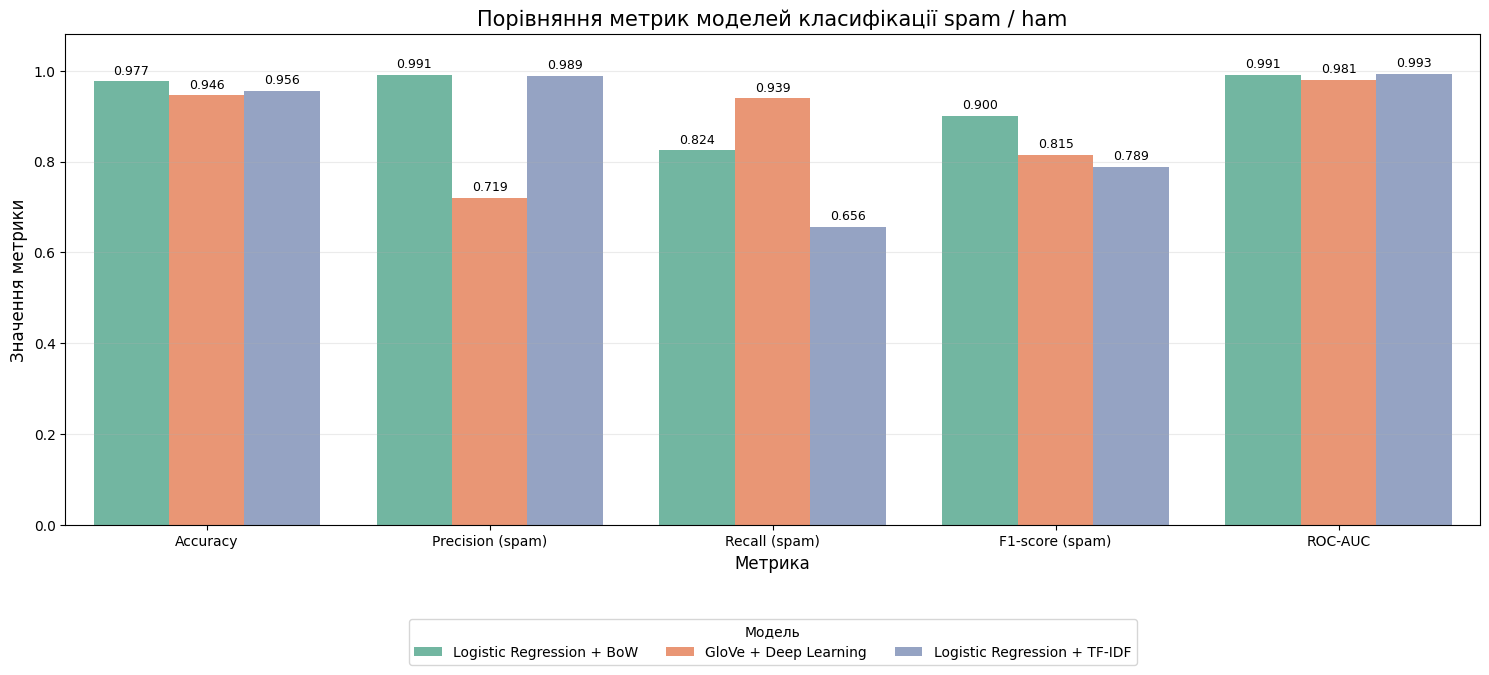

In [36]:
# ==========================================================
# КРОК 6.2. Графічне порівняння метрик моделей
# ==========================================================

# Перетворюємо широку таблицю у довгий формат для seaborn.
metrics_to_plot = [
    "Accuracy",
    "Precision (spam)",
    "Recall (spam)",
    "F1-score (spam)",
    "ROC-AUC"
]

results_long = results_df.melt(
    id_vars="Модель",
    value_vars=metrics_to_plot,
    var_name="Метрика",
    value_name="Значення"
)

# Будуємо групований стовпчиковий графік.
plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=results_long,
    x="Метрика",
    y="Значення",
    hue="Модель",
    palette="Set2"
)

plt.title("Порівняння метрик моделей класифікації spam / ham", fontsize=15)
plt.xlabel("Метрика", fontsize=12)
plt.ylabel("Значення метрики", fontsize=12)

# Межі від 0 до 1 потрібні, бо всі використані метрики нормовані.
plt.ylim(0, 1.08)

# Підписуємо значення над кожним стовпчиком.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.legend(
    title="Модель",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=3
)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Загальні висновки

У роботі було побудовано та порівняно три моделі класифікації електронних
повідомлень на класи `ham` і `spam`:

1. Logistic Regression + Bag of Words;
2. Logistic Regression + TF-IDF;
3. GloVe + Deep Learning.

Для підготовки даних було виконано очищення тексту: переведення до нижнього регістру, видалення URL-адрес, HTML-тегів, цифр, спеціальних символів і англійських стоп-слів. Також було видалено 403 повні дублікати, після чого
залишилося 5 169 унікальних повідомлень. Дані були розділені на навчальну та валідаційну вибірки у співвідношенні 80% / 20% зі стратифікацією за цільовим класом.

Датасет є незбалансованим: клас `ham` становить 87.37% повідомлень, а клас `spam` — 12.63%. Тому Accuracy не використовувалась як єдина метрика якості. Для повної оцінки моделей було застосовано Accuracy, Precision, Recall,
F1-score та ROC-AUC. 

### Порівняння моделей

Найкращий F1-score для класу `spam` показала модель Logistic Regression + BoW: F1-score = 0.9000, Accuracy = 0.9768, Precision = 0.9908, Recall = 0.8244, ROC-AUC = 0.9907.

BoW-модель є найбільш збалансованою. Вона має Вона має найвищу Accuracy та F1-score, майже не позначає легітимні повідомлення як спам і водночас знаходить більшість небажаних листів. У валідаційній вибірці модель допустила лише 1 False Positive, тобто лише одне легітимне повідомлення було помилково класифіковане як спам.

Модель Logistic Regression + TF-IDF має найвищий ROC-AUC = 0.9928, що вказує на відмінне розділення класів за прогнозованими імовірностями. Проте за стандартного порогу класифікації 0.5 вона має нижчий Recall = 0.6565 та пропускає значну частину спам-повідомлень. Отже, цю модель доцільно використовувати після додаткового налаштування порогу класифікації.

Модель GloVe + Deep Learning показала найвищий Recall = 0.9389. Вона виявила 123 з 131 спам-повідомлення та пропустила лише 8. Проте Precision становить 0.7193: 48 легітимних повідомлень були помилково позначені як спам. Це є
наслідком використання class_weight, який збільшує важливість рідкісного класу `spam` і робить модель більш чутливою до небажаних листів.

### Вибір найкращої моделі

Найкращою моделлю для цієї задачі обрано Logistic Regression + Bag of Words.

Вона має найвищий F1-score = 0.9000, найвищу Accuracy = 0.9768 і дуже високу Precision = 0.9908. Такий баланс є практично корисним для поштового фільтра: модель надійно виявляє спам і майже не блокує легітимні повідомлення.


### Можливі напрями покращення

1. Налаштувати поріг класифікації для TF-IDF і GloVe-моделей замість стандартного значення 0.5.
2. Виконати підбір гіперпараметрів Logistic Regression: параметра регуляризації C, типу penalty та class_weight.